# Explore the FINAL Sonnet tags

Interactive viewer for the re-tagged dataset in `dataset/gateway_tags_final/` — all 9,298 images tagged with
**Claude 4.5 Sonnet** using the standards-grounded, human-tuned definitions (`definitions.py`).

This is the replacement for the Gemma tags. Pick one or more tags on the left and the grid shows matching
images with their predicted tags (selected tags marked with `*`). Choose a dataset, `any` vs `all` match, and
how many images to show. The same logic is available from the CLI via `viz_manifest.py`.

> Note: the final tags are JSON-Lines (one record per image), so we load them with `v.load_gateway(...)`
> instead of `v.load(...)` (which reads the old single-object manifests).

In [8]:
# pip install ipywidgets matplotlib

In [9]:
%matplotlib inline
import glob
import matplotlib.pyplot as plt
import ipywidgets as W
from IPython.display import display, clear_output
import viz_manifest as v

# all four datasets' final Sonnet tags
PATHS = sorted(glob.glob('../dataset/gateway_tags_final/*.tags.jsonl'))
samples = v.load_gateway(PATHS)
counts  = v.tag_counts(samples)
print(f'{len(samples):,} images · {len(counts)} tags seen · datasets: {v.datasets(samples)}')
print('files:', [p.split("/")[-1] for p in PATHS])

9,298 images · 40 tags seen · datasets: ['bdd100k', 'culane', 'curvelanes', 'tusimple']
files: ['gateway_tags_final\\bdd100k.tags.jsonl', 'gateway_tags_final\\culane.tags.jsonl', 'gateway_tags_final\\curvelanes.tags.jsonl', 'gateway_tags_final\\tusimple.tags.jsonl']


## Tag distribution by dimension

How often each tag fires across the whole set — a quick sanity check on the new tags (e.g. how many images
carry `Unmarked Pavement`, how often `Faded / Worn` co-occurs with `Low Contrast`).

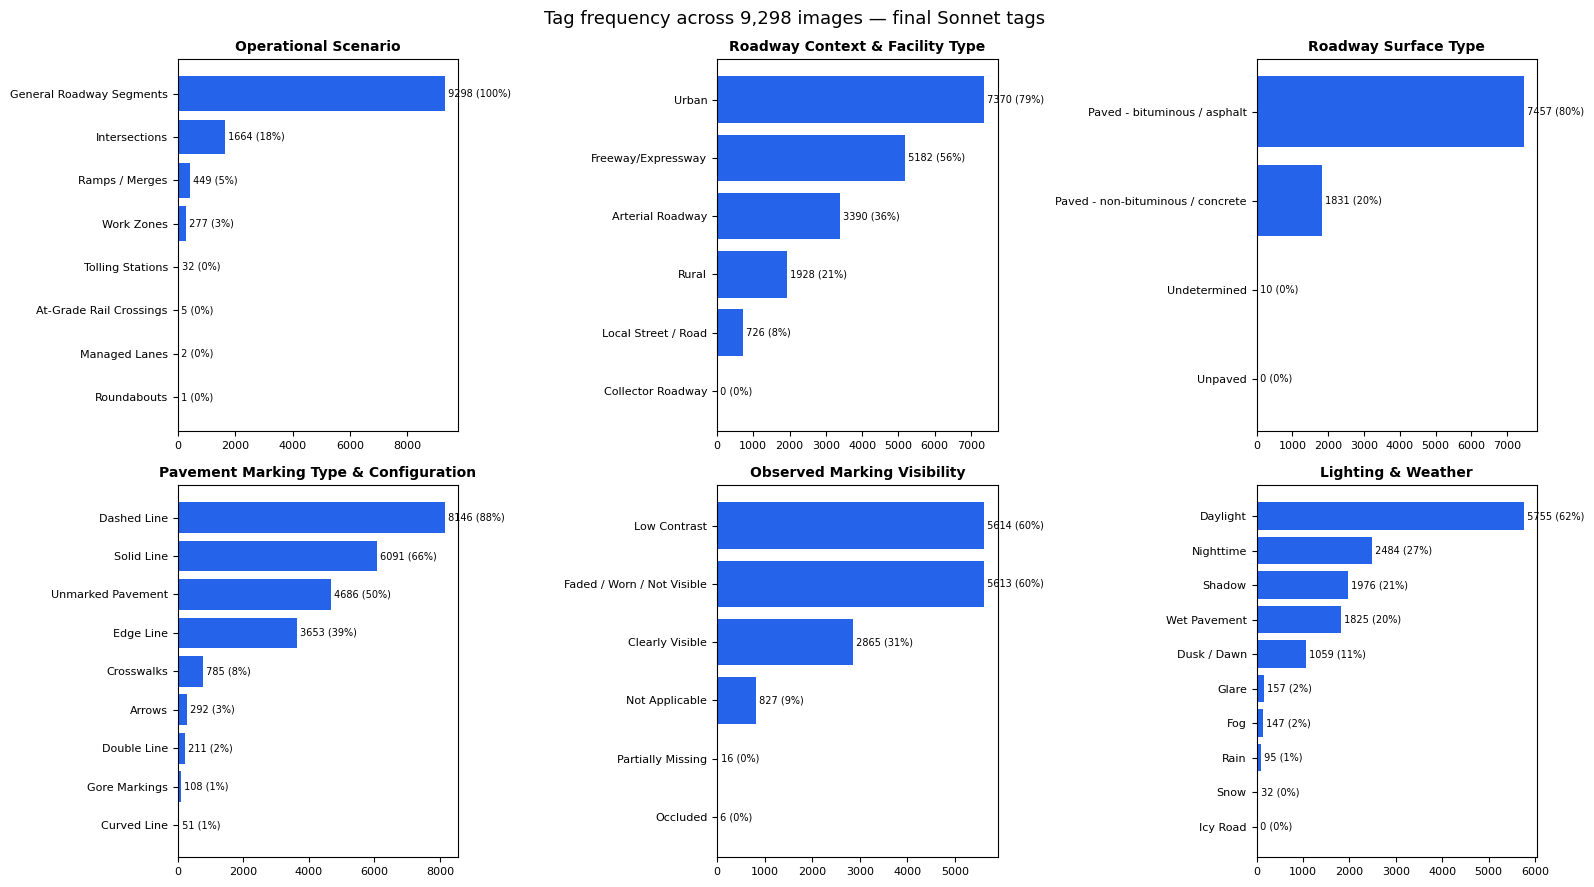

In [10]:
from taxonomy import TAXONOMY

n = len(samples)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (dim, tags) in zip(axes.flat, TAXONOMY.items()):
    names = list(tags)
    vals  = [counts.get(t, 0) for t in names]
    order = sorted(range(len(names)), key=lambda i: vals[i])
    names = [names[i] for i in order]; vals = [vals[i] for i in order]
    ax.barh(names, vals, color='#2563eb')
    ax.set_title(dim, fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=8)
    for i, val in enumerate(vals):
        ax.text(val, i, f' {val} ({val/n*100:.0f}%)', va='center', fontsize=7)
fig.suptitle(f'Tag frequency across {n:,} images — final Sonnet tags', fontsize=13)
fig.tight_layout()
plt.show()

## Interactive tag picker

Select tags (Ctrl/Shift-click for multiple), choose dataset / match-mode / counts, and browse the images.

9298 image(s) match tags=any mode=any dataset=all; showing up to 12


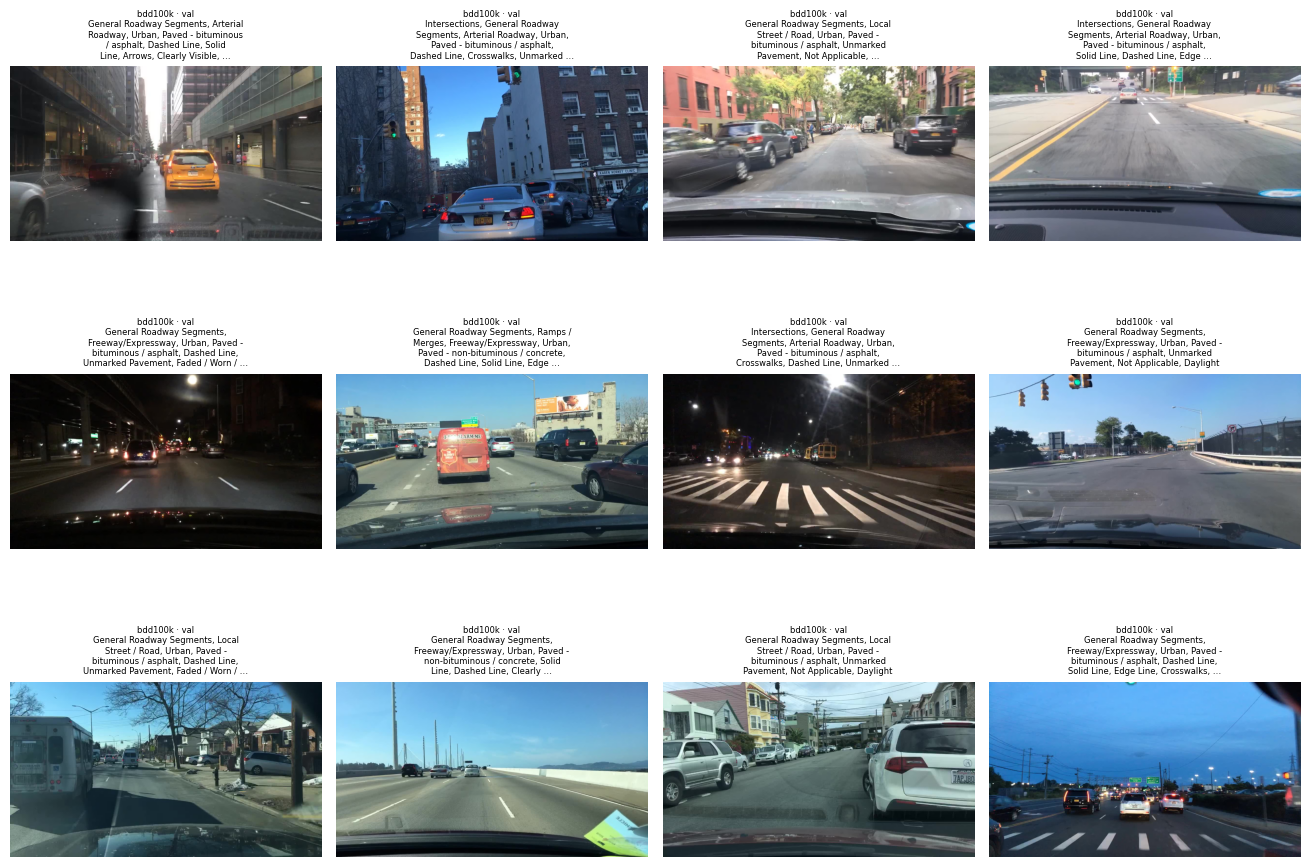

In [11]:
opts    = [f'{t}  ({c})' for t, c in counts.most_common()]
to_name = {f'{t}  ({c})': t for t, c in counts.most_common()}

tags_w = W.SelectMultiple(options=opts, description='Tags', rows=16,
                          layout=W.Layout(width='340px'))
ds_w   = W.Dropdown(options=['all'] + v.datasets(samples), description='Dataset')
mode_w = W.ToggleButtons(options=['any', 'all'], description='Match',
                         tooltips=['has ANY selected tag', 'has ALL selected tags'])
n_w    = W.IntSlider(value=12, min=1, max=48, description='Max imgs')
cols_w = W.IntSlider(value=4,  min=1, max=6,  description='Cols')
out    = W.Output()

def render(*_):
    with out:
        clear_output(wait=True)
        tags = [to_name[o] for o in tags_w.value]
        ds   = None if ds_w.value == 'all' else ds_w.value
        v.view(samples, tags=tags, mode=mode_w.value, dataset=ds,
               cols=cols_w.value, max_n=n_w.value)
        plt.show()

for w in (tags_w, ds_w, mode_w, n_w, cols_w):
    w.observe(render, names='value')

display(W.HBox([tags_w, W.VBox([ds_w, mode_w, n_w, cols_w])]), out)
render()

### One-liners (no widgets)
`v.view(samples, tags=['Nighttime', 'Glare'], mode='all', max_n=12)` — images with **both** tags.

`v.view(samples, tags=['Unmarked Pavement'], dataset='culane')` — filter to one dataset.

`v.view(samples, tags=['Crosswalks'], max_n=16, save='crosswalks.png')` — write a PNG.

5613 image(s) match tags=['Faded / Worn / Not Visible', 'Low Contrast'] mode=all dataset=all; showing up to 12


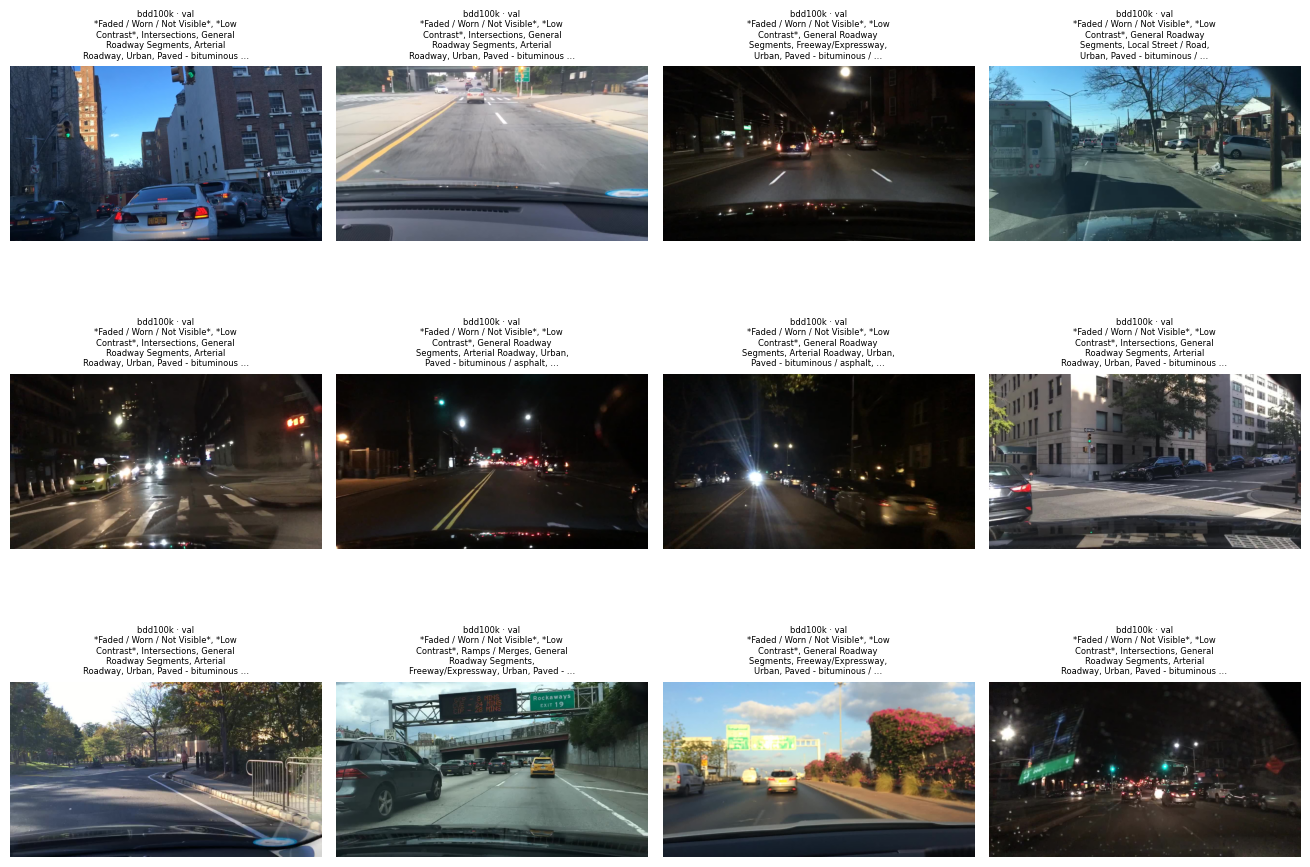

In [12]:
# example: faded/worn markings that are also low-contrast (the readability cases)
v.view(samples, tags=['Faded / Worn / Not Visible', 'Low Contrast'], mode='all', max_n=12)
plt.show()

## Inspect a single image with the model's reasoning

The final tags carry a short per-dimension `why` from the model. This shows the image plus its full
by-dimension tags and reasoning — useful for spot-checking / adjudicating.

3622 partial-coverage images; showing the first:



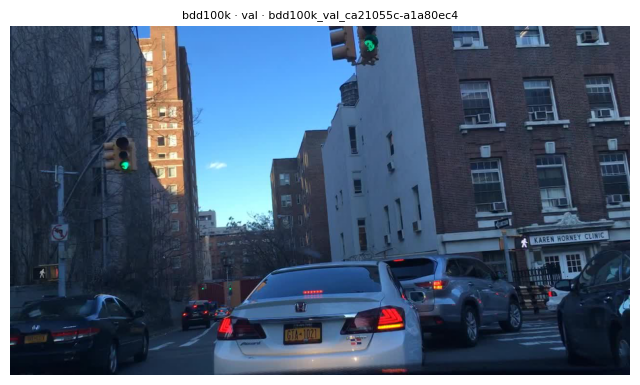

▸ Operational Scenario
    tags: ['Intersections', 'General Roadway Segments']
    why : Traffic signal overhead showing green, crosswalk visible ahead, vehicles stopped at intersection approach.
▸ Roadway Context & Facility Type
    tags: ['Arterial Roadway', 'Urban']
    why : Multi-lane road with buildings, sidewalks, traffic signals, commercial frontage, dense urban development.
▸ Roadway Surface Type
    tags: ['Paved - bituminous / asphalt']
    why : Continuous dark surface with granular texture, no visible transverse slab joints.
▸ Pavement Marking Type & Configuration
    tags: ['Dashed Line', 'Crosswalks', 'Unmarked Pavement']
    why : Dashed lane dividers visible, crosswalk bars ahead, but large areas lack edge/shoulder markings.
▸ Observed Marking Visibility
    tags: ['Faded / Worn / Not Visible', 'Low Contrast']
    why : Lane markings are dull, worn, and blend into dark pavement with poor contrast.
▸ Lighting & Weather
    tags: ['Daylight']
    why : Bright blue sky, f

In [5]:
from PIL import Image

def show_with_reasoning(sample):
    pt = sample['meta']['predicted_tags']
    by_dim = pt.get('by_dimension', {})
    why    = pt.get('reasoning', {})
    fig, ax = plt.subplots(figsize=(8, 5))
    try:
        ax.imshow(Image.open(v.resolve_image(sample)).convert('RGB'))
    except Exception as e:
        ax.text(0.5, 0.5, f'[image unavailable] {e}', ha='center')
    ax.axis('off')
    ax.set_title(f"{sample['dataset']} · {sample.get('split','')} · {sample['sample_id']}", fontsize=8)
    plt.show()
    for dim in by_dim:
        print(f"▸ {dim}")
        print(f"    tags: {by_dim[dim]}")
        if why.get(dim):
            print(f"    why : {why[dim]}")

# pick the first image that has 'Unmarked Pavement' alongside line tags (partial coverage)
cands = [s for s in samples
         if 'Unmarked Pavement' in v._labels(s) and len(set(v._labels(s)) & set(
             ['Solid Line','Dashed Line','Edge Line','Double Line'])) > 0]
print(f'{len(cands)} partial-coverage images; showing the first:\n')
show_with_reasoning(cands[0])